Setup and imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load yearly files from csv from 2019 to 2024.
Data from https://www.aemet.es/es/datos_abiertos/estadisticas/vigilancia_clima 

In [ ]:
import glob

files = glob.glob("../data/raw/PREC_*.csv") # list of all precipitation files

df_list = [] # empty list to hold dataframes

for f in files: # loop to read each file and append to list
    df = pd.read_csv(f, sep=";", encoding="latin-1")
    df["source_file"] = f
    df_list.append(df)

df = pd.concat(df_list, ignore_index=True)
print(df)

         Parámetro             región  enero  febrero  marzo  abril  mayo  \
0    Precipitación           A CORUÑA  171.2     72.0   96.1  173.7  52.9   
1    Precipitación           ALBACETE   18.8      5.0   19.4  159.8   8.6   
2    Precipitación   ALICANTE/ALACANT    2.1      0.8   34.1  180.4   6.2   
3    Precipitación            ALMERIA    2.9      4.3   14.2   55.8   1.9   
4    Precipitación        ARABA/ALAVA  193.5     49.2   27.6   79.5  61.6   
..             ...                ...    ...      ...    ...    ...   ...   
307  Precipitación             TOLEDO   94.2     41.9  134.1    9.7   8.3   
308  Precipitación  VALENCIA/VALÈNCIA   27.5     12.2   44.9    7.9   4.2   
309  Precipitación         VALLADOLID   63.7     35.8   69.5   23.4  40.9   
310  Precipitación             ZAMORA   77.8     44.5  107.0   38.7  42.3   
311  Precipitación           ZARAGOZA   38.5     39.3   56.1   11.8  30.7   

     junio  julio  agosto  septiembre  octubre  noviembre  diciembre   anua

Basic cleaning: standarize to lowercase column names

In [60]:
df.columns = df.columns.str.strip().str.lower()
print(df.columns)


Index(['parámetro', 'región', 'enero', 'febrero', 'marzo', 'abril', 'mayo',
       'junio', 'julio', 'agosto', 'septiembre', 'octubre', 'noviembre',
       'diciembre', 'anual', 'source_file'],
      dtype='str')


Reshape to long format: year/month/region/precipitation

In [ ]:
month_cols = ["enero","febrero","marzo","abril","mayo","junio",
              "julio","agosto","septiembre","octubre","noviembre","diciembre"]

df_long = df.melt(
    id_vars=["región", "source_file"],
    value_vars=month_cols,
    var_name="month",
    value_name="precipitation"
)
print(df_long.head())


             región                           source_file  month  \
0          A CORUÑA  ../data/raw\PREC_2019_Provincias.csv  enero   
1          ALBACETE  ../data/raw\PREC_2019_Provincias.csv  enero   
2  ALICANTE/ALACANT  ../data/raw\PREC_2019_Provincias.csv  enero   
3           ALMERIA  ../data/raw\PREC_2019_Provincias.csv  enero   
4       ARABA/ALAVA  ../data/raw\PREC_2019_Provincias.csv  enero   

   precipitation  
0          171.2  
1           18.8  
2            2.1  
3            2.9  
4          193.5  


Add year labels from file name by extracting 4-digit sequence

In [ ]:
df_long["year"] = df_long["source_file"].str.extract(r"(\d{4})").astype(int)
cols = ["región", "year", "month", "precipitation", "source_file"] # reorder columns
df_long = df_long[cols]
print(df_long.head())

             región  year  month  precipitation  \
0          A CORUÑA  2019  enero          171.2   
1          ALBACETE  2019  enero           18.8   
2  ALICANTE/ALACANT  2019  enero            2.1   
3           ALMERIA  2019  enero            2.9   
4       ARABA/ALAVA  2019  enero          193.5   

                            source_file  
0  ../data/raw\PREC_2019_Provincias.csv  
1  ../data/raw\PREC_2019_Provincias.csv  
2  ../data/raw\PREC_2019_Provincias.csv  
3  ../data/raw\PREC_2019_Provincias.csv  
4  ../data/raw\PREC_2019_Provincias.csv  


Add time structure (numbered months). to_datetime uses english months

In [ ]:
month_map = {
    "enero":1, "febrero":2, "marzo":3, "abril":4,
    "mayo":5, "junio":6, "julio":7, "agosto":8,
    "septiembre":9, "octubre":10, "noviembre":11, "diciembre":12
}

df_long["month_num"] = df_long["month"].map(month_map)
df_long["date"] = pd.to_datetime( # mapping year and month to datetime
    dict(year=df_long["year"], month=df_long["month_num"], day=1)
) 
print(df_long.head())

             región  year  month  precipitation  \
0          A CORUÑA  2019  enero          171.2   
1          ALBACETE  2019  enero           18.8   
2  ALICANTE/ALACANT  2019  enero            2.1   
3           ALMERIA  2019  enero            2.9   
4       ARABA/ALAVA  2019  enero          193.5   

                            source_file  month_num       date  
0  ../data/raw\PREC_2019_Provincias.csv          1 2019-01-01  
1  ../data/raw\PREC_2019_Provincias.csv          1 2019-01-01  
2  ../data/raw\PREC_2019_Provincias.csv          1 2019-01-01  
3  ../data/raw\PREC_2019_Provincias.csv          1 2019-01-01  
4  ../data/raw\PREC_2019_Provincias.csv          1 2019-01-01  


Plot average precipitation by region

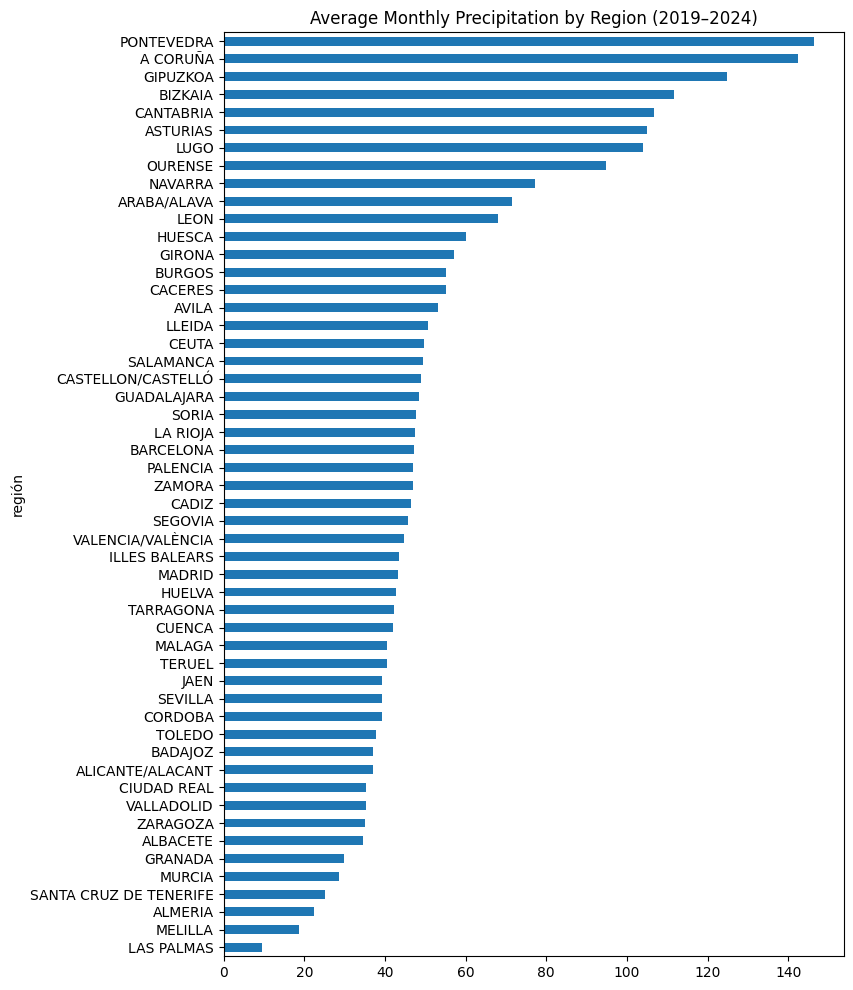

In [ ]:
region_avg = df_long.groupby("región")["precipitation"].mean().sort_values()

region_avg.plot(kind="barh", figsize=(8,12))
plt.title("Average Monthly Precipitation by Region (2019–2024)")
plt.show()

In [ ]:

# -----------------------------
# BASIC CLEANING
# -----------------------------
df.columns = df.columns.str.strip().str.lower()
print(df.columns)

# -----------------------------
# FILTER GALICIA REGIONS
# -----------------------------
galicia_regions = ["A CORUÑA", "LUGO", "OURENSE", "PONTEVEDRA"]

df_galicia = df_long[df_long["región"].isin(galicia_regions)]

# -----------------------------
# CLEAN DATA
# -----------------------------
df_galicia["precipitation"] = pd.to_numeric(df_galicia["precipitation"], errors="coerce")

# -----------------------------
# AGGREGATE (2019–2024 mean monthly precipitation)
# -----------------------------
region_avg = (
    df_galicia
    .groupby("región")["precipitation"]
    .mean()
    .sort_values()
)

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(8, 5))
region_avg.plot(kind="barh")

plt.title("Average Monthly Precipitation in Galicia (2019–2024)")
plt.xlabel("Average monthly precipitation (mm)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

Galicia focus subset time series (annual). Does is actually rain more in coruna than other regions?

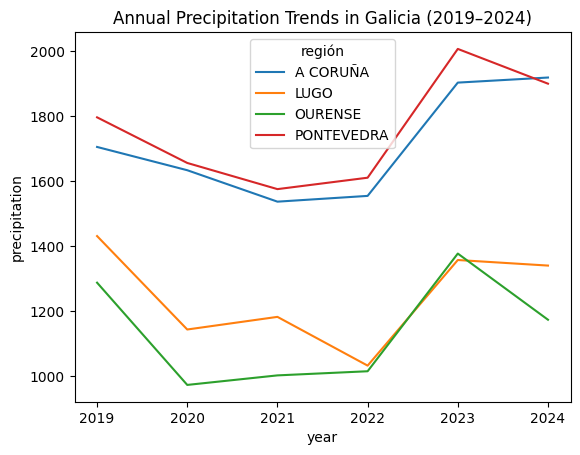

In [ ]:
galicia = df_long[df_long["región"].isin([
    "A CORUÑA", "LUGO", "OURENSE", "PONTEVEDRA"
])]

galicia_yearly = galicia.groupby(["year","región"])["precipitation"].sum().reset_index()

sns.lineplot(data=galicia_yearly, x="year", y="precipitation", hue="región")
plt.title("Annual Precipitation Trends in Galicia (2019–2024)")
plt.show()

Comparison of monthly rainfall by region - seasonal patterns? On average over the past 5 years.

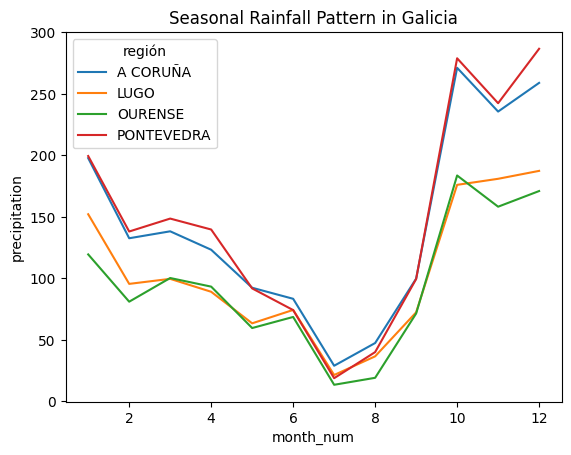

In [ ]:
seasonality = galicia.groupby(["región","month_num"])["precipitation"].mean().reset_index()

sns.lineplot(data=seasonality, x="month_num", y="precipitation", hue="región")
plt.title("Seasonal Rainfall Pattern in Galicia")
plt.show()

Precipitation anomalies from OVERALL mean 

Overall mean precipitation in Galicia: 121.93 mm


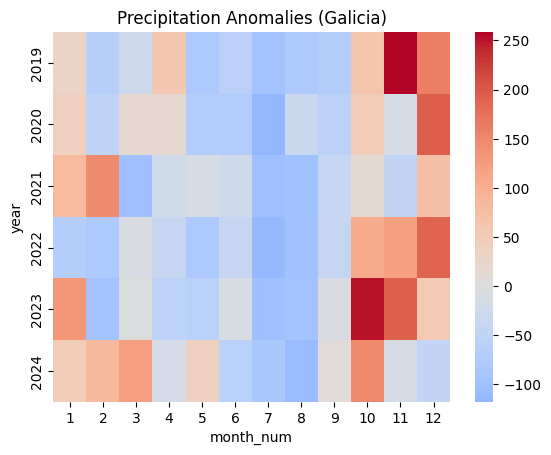

In [ ]:
overall_mean = galicia["precipitation"].mean()
print(f"Overall mean precipitation in Galicia: {overall_mean:.2f} mm")
galicia["anomaly"] = galicia["precipitation"] - overall_mean

pivot = galicia.pivot_table(
    values="anomaly",
    index="year",
    columns="month_num"
)

sns.heatmap(pivot, cmap="coolwarm", center=0)
plt.title("Precipitation Anomalies (Galicia)")
plt.show()

Refine the above graph to compare with monthly mean

month_num
1     167.100000
2     111.754167
3     121.616667
4     111.279167
5      76.783333
6      75.108333
7      20.695833
8      35.808333
9      85.716667
10    227.291667
11    204.170833
12    225.837500
Name: precipitation, dtype: float64


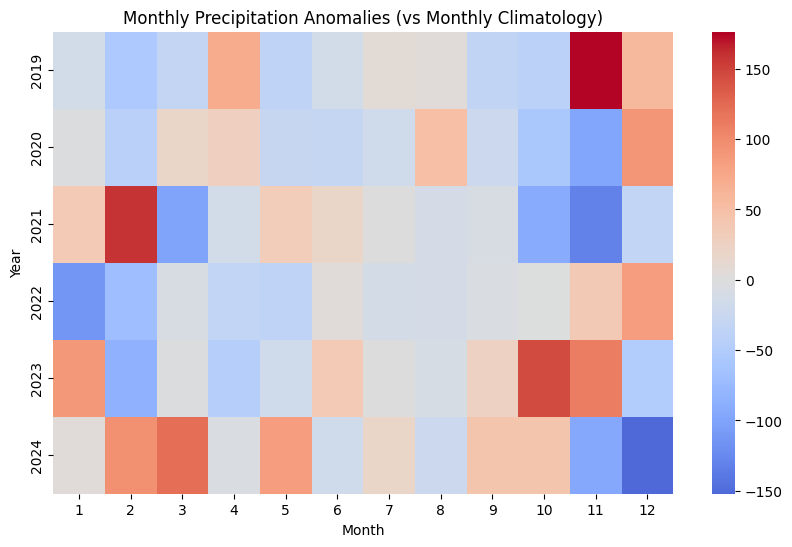

In [ ]:
# calculate monthly mean precipitations across all years for Galicia
monthly_mean = galicia.groupby("month_num")["precipitation"].mean()
print(monthly_mean)

# map monthly means back to the original dataframe and calculate anomalies
galicia["monthly_mean"] = galicia["month_num"].map(monthly_mean)
galicia["anomaly"] = galicia["precipitation"] - galicia["monthly_mean"]

# pivot for heatmap of anomalies by year and month
pivot = galicia.pivot_table(
    values="anomaly",
    index="year",
    columns="month_num"
)

galicia.to_csv("C:\\Users\\Equipo\\Documents\\ss_ML_local\\galicia-climate-analysis\\outputs\\galicia_with_anomalies.csv", index=False) # export data to csv

# plot heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(pivot, cmap="coolwarm", center=0)

plt.title("Monthly Precipitation Anomalies (vs Monthly Climatology)")
plt.xlabel("Month")
plt.ylabel("Year")

plt.show()


Try again: santiago region specifically. 

month_num
1     167.100000
2     111.754167
3     121.616667
4     111.279167
5      76.783333
6      75.108333
7      20.695833
8      35.808333
9      85.716667
10    227.291667
11    204.170833
12    225.837500
Name: precipitation, dtype: float64


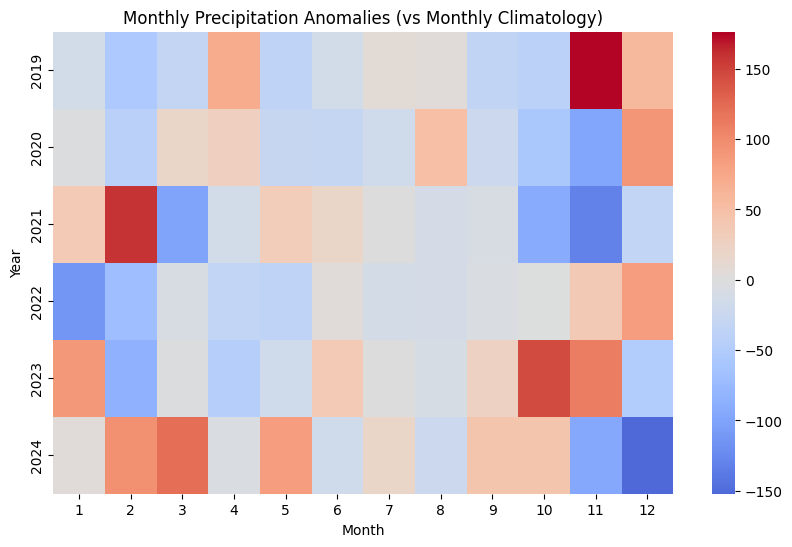

In [ ]:
# calculate monthly mean precipitations across all years for Galicia
monthly_mean = galicia.groupby("month_num")["precipitation"].mean()
print(monthly_mean)

# map monthly means back to the original dataframe and calculate anomalies
galicia["monthly_mean"] = galicia["month_num"].map(monthly_mean)
galicia["anomaly"] = galicia["precipitation"] - galicia["monthly_mean"]

# pivot for heatmap of anomalies by year and month
pivot = galicia.pivot_table(
    values="anomaly",
    index="year",
    columns="month_num"
)

galicia.to_csv("C:\\Users\\Equipo\\Documents\\ss_ML_local\\galicia-climate-analysis\\outputs\\galicia_with_anomalies.csv", index=False) # export data to csv

# plot heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(pivot, cmap="coolwarm", center=0)

plt.title("Monthly Precipitation Anomalies (vs Monthly Climatology)")
plt.xlabel("Month")
plt.ylabel("Year")

plt.show()


Precipitation anomalies chart - over the years are monthly values changing?

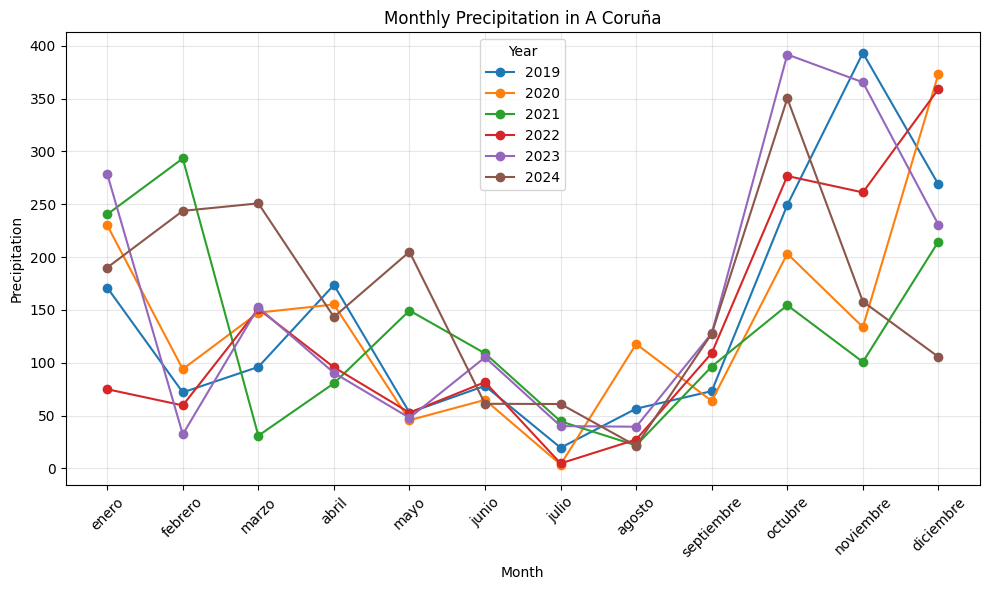

In [ ]:
# focus on A Coruña region
df_coruna = df_long[df_long["región"].str.contains("Coruña", case=False, na=False)] # filter for A Coruña region

month_order = [
    "enero","febrero","marzo","abril","mayo","junio",
    "julio","agosto","septiembre","octubre","noviembre","diciembre"
]
 
# set month with specified order and sort
df_coruna["month"] = pd.Categorical(df_coruna["month"], categories=month_order, ordered=True)
df_coruna = df_coruna.sort_values("month")

plt.figure(figsize=(10,6))

# pivot for plotting (one line per year)
for year, group in df_coruna.groupby("year"):
    monthly = group.groupby("month")["precipitation"].mean()
    plt.plot(monthly.index, monthly.values, marker="o", label=str(year))

# plot style
plt.title("Monthly Precipitation in A Coruña")
plt.xlabel("Month")
plt.ylabel("Precipitation")
plt.legend(title="Year")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Load your spreadsheet (replace 'precipitation_data.csv' with your actual file path)
# If it's an Excel file, use pd.read_excel() instead
df = pd.read_csv("C:\Users\Equipo\Downloads\galicia_climate_data_1997_2026.xlsx")

# 2. Filter for the requested years (1997 to 2026)
df = df[(df["year"] >= 1997) & (df["year"] <= 2026)]

# 3. Reshape from wide format (months as columns) to long format
month_columns = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]
df_long = pd.melt(
    df,
    id_vars=["year", "station_id"],
    value_vars=month_columns,
    var_name="month",
    value_name="precipitation",
)

# 4. Calculate the monthly average across all stations for each year and month
galicia = (
    df_long.groupby(["year", "month"])["precipitation"].mean().reset_index()
)

# 5. Calculate overall mean and precipitation anomalies
overall_mean = galicia["precipitation"].mean()
print(f"Overall mean precipitation in Galicia: {overall_mean:.2f} mm")
galicia["anomaly"] = galicia["precipitation"] - overall_mean

# 6. Pivot the data: Months on Y-axis (index), Years on X-axis (columns)
pivot = galicia.pivot_table(values="anomaly", index="month", columns="year")

# 7. Ensure the months are ordered chronologically instead of alphabetically
pivot = pivot.reindex(month_columns)

# 8. Plot the heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap="coolwarm", center=0, cbar_kws={"label": "Anomaly (mm)"})

plt.title("Precipitation Anomalies in Galicia (1997-2026)")
plt.xlabel("Year")
plt.ylabel("Month")
plt.tight_layout()
plt.show()